## Importing Libraries

In [5]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")




Libraries imported successfully!


In [6]:
filePath="../dataSet/bank-full.csv"

df=pd.read_csv(filePath,sep=';')

print("Imported dataSet")

Imported dataSet


## Basic Data Analysis

In [7]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [8]:
df.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,no


In [9]:
df.sample(5, random_state=67)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
40210,28,technician,single,secondary,no,1363,no,no,cellular,9,jun,431,3,102,1,success,no
26727,30,management,married,secondary,no,3817,yes,no,cellular,20,nov,104,5,-1,0,unknown,no
24873,35,blue-collar,married,secondary,no,153,yes,no,cellular,18,nov,645,2,-1,0,unknown,no
17861,37,technician,single,secondary,no,103,yes,no,cellular,30,jul,124,3,-1,0,unknown,no
31534,34,technician,divorced,secondary,no,705,yes,yes,cellular,2,apr,249,1,-1,0,unknown,no


In [10]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 45211
Number of columns: 17


In [11]:
print("Columns in the dataset:")
for column in df.columns:
    print(column)

Columns in the dataset:
age
job
marital
education
default
balance
housing
loan
contact
day
month
duration
campaign
pdays
previous
poutcome
y


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 8.1 MB


In [13]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [14]:
missing_values = df.isnull().sum().sum()

print("Missing values in each column:", missing_values)

Missing values in each column: 0


In [15]:
print("Duplicate Rows: ",df.duplicated().sum())

Duplicate Rows:  0


## Visual EDA

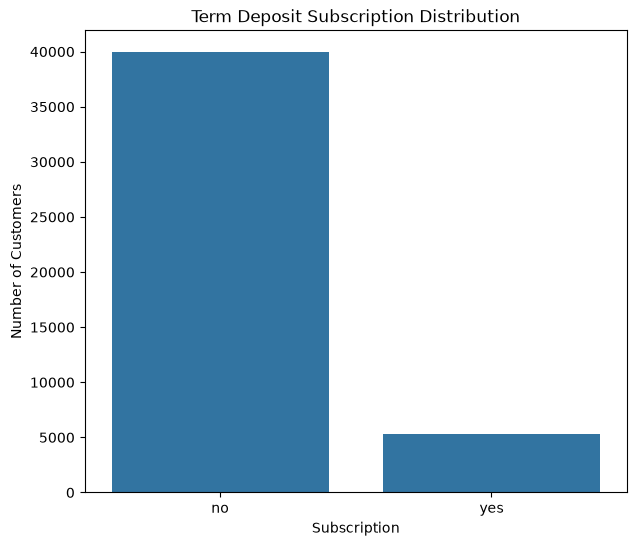

In [16]:
plt.figure(figsize=(7,6))

sns.countplot(data=df, x="y")

plt.title("Term Deposit Subscription Distribution")
plt.xlabel("Subscription")
plt.ylabel("Number of Customers")

plt.show()

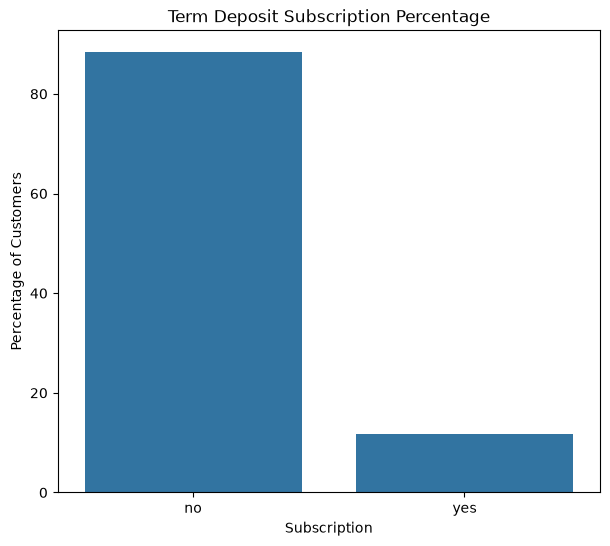

In [17]:
target_percentage = df["y"].value_counts(normalize=True) * 100

plt.figure(figsize=(7,6))

sns.barplot(
    x=target_percentage.index,
    y=target_percentage.values
)

plt.title("Term Deposit Subscription Percentage")
plt.xlabel("Subscription")
plt.ylabel("Percentage of Customers")

plt.show()

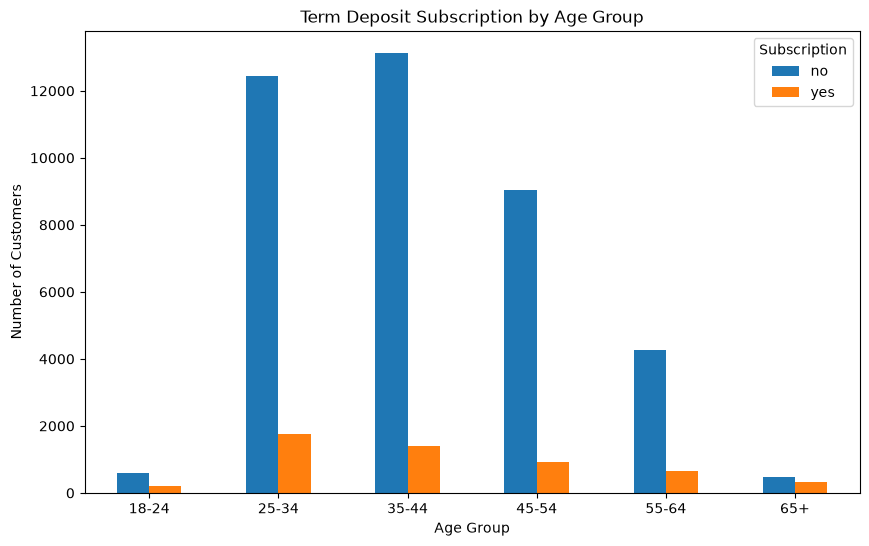

In [18]:
age_bins = [18, 25, 35, 45, 55, 65, 100]

age_labels = [
    "18-24",
    "25-34",
    "35-44",
    "45-54",
    "55-64",
    "65+"
]

df["age_group"] = pd.cut(
    df["age"],
    bins=age_bins,
    labels=age_labels,
    right=False
)

age_target = pd.crosstab(
    df["age_group"],
    df["y"]
)

age_target.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Term Deposit Subscription by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Subscription")

plt.show()

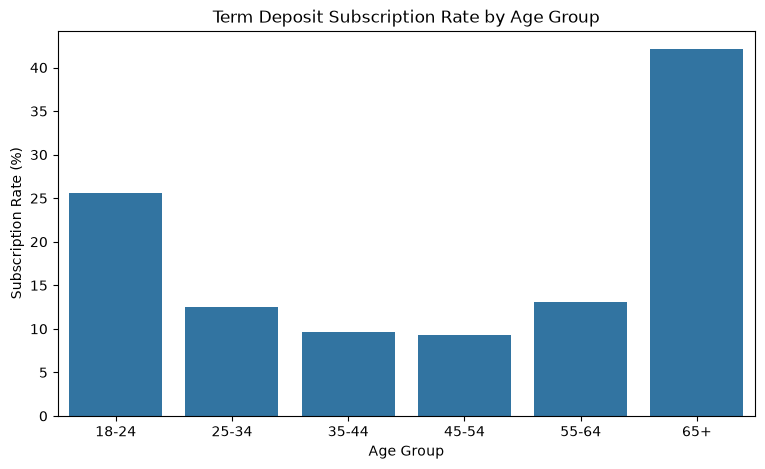

In [19]:
age_subscription_rate = (
    pd.crosstab(
        df["age_group"],
        df["y"],
        normalize="index"
    )["yes"] * 100
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=age_subscription_rate.index,
    y=age_subscription_rate.values
)

plt.title("Term Deposit Subscription Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Subscription Rate (%)")

plt.show()

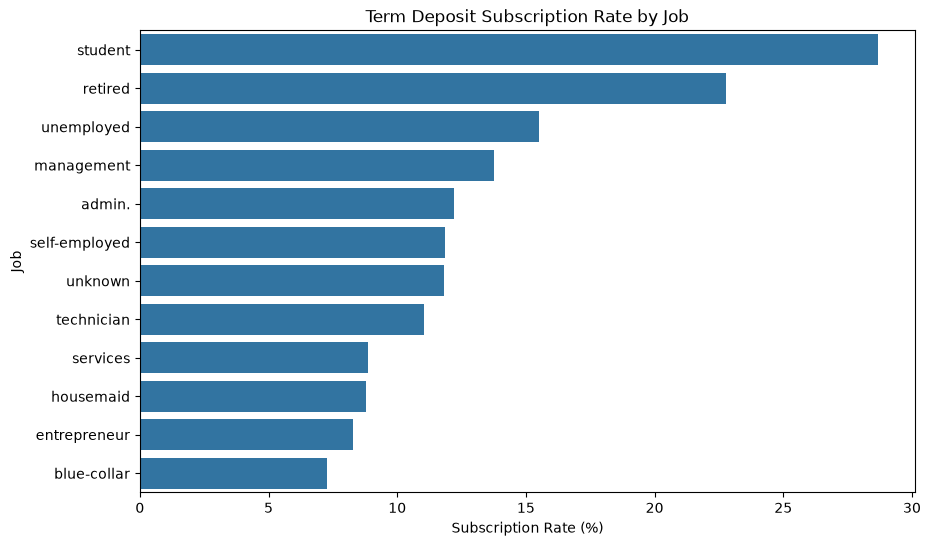

In [20]:
job_rate = (
    pd.crosstab(df["job"], df["y"], normalize="index")["yes"] * 100
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=job_rate.values,
    y=job_rate.index
)

plt.title("Term Deposit Subscription Rate by Job")
plt.xlabel("Subscription Rate (%)")
plt.ylabel("Job")

plt.show()

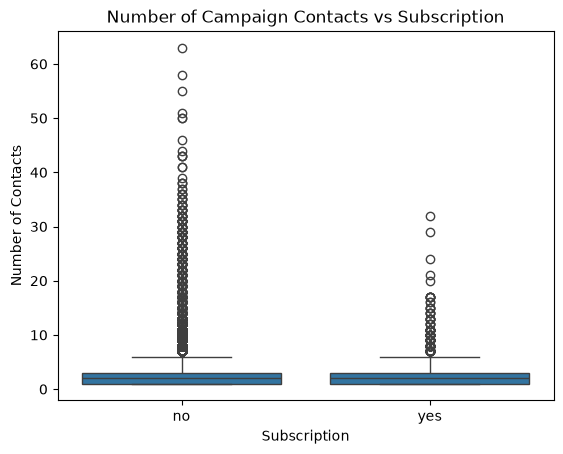

In [21]:
sns.boxplot(
    data=df,
    x="y",
    y="campaign"
)

plt.title("Number of Campaign Contacts vs Subscription")
plt.xlabel("Subscription")
plt.ylabel("Number of Contacts")

plt.show()

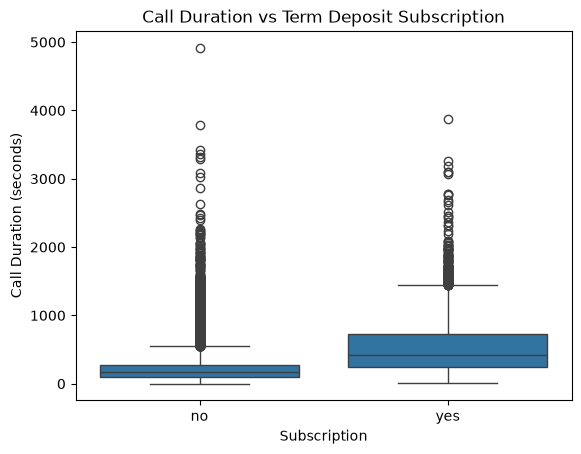

In [22]:
sns.boxplot(
    data=df,
    x="y",
    y="duration"
)

plt.title("Call Duration vs Term Deposit Subscription")
plt.xlabel("Subscription")
plt.ylabel("Call Duration (seconds)")

plt.show()

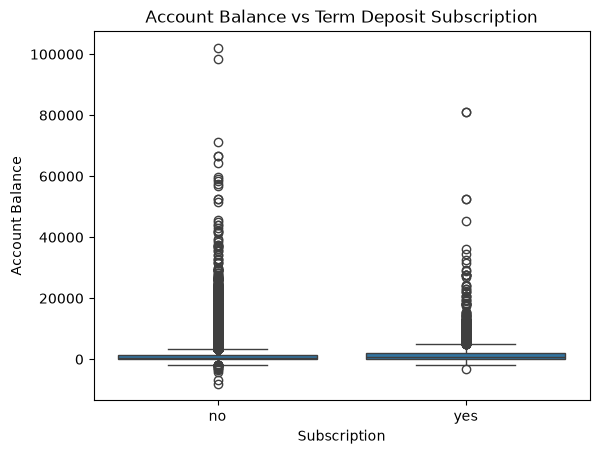

In [23]:
sns.boxplot(
    data=df,
    x="y",
    y="balance"
)

plt.title("Account Balance vs Term Deposit Subscription")
plt.xlabel("Subscription")
plt.ylabel("Account Balance")

plt.show()

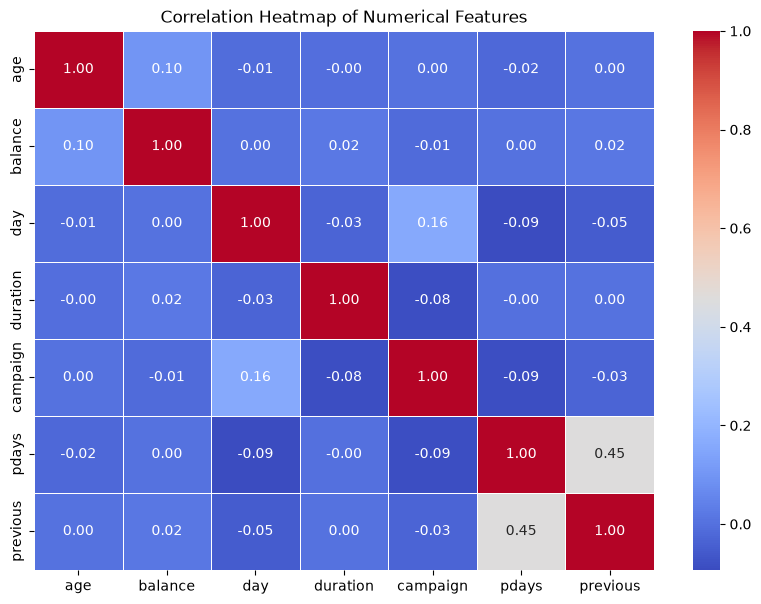

In [24]:
numeric_columns = [
    "age",
    "balance",
    "day",
    "duration",
    "campaign",
    "pdays",
    "previous"
]

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")

plt.show()

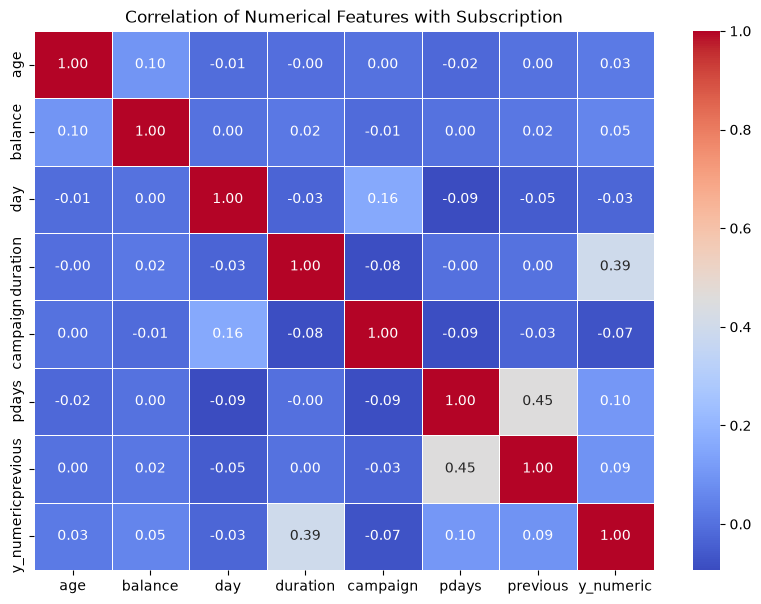

In [25]:
df["y_numeric"] = df["y"].map({
    "no": 0,
    "yes": 1
})

heatmap_columns = [
    "age",
    "balance",
    "day",
    "duration",
    "campaign",
    "pdays",
    "previous",
    "y_numeric"
]

correlation_matrix = df[heatmap_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation of Numerical Features with Subscription")

plt.show()

### Unknown Value Analysis
The dataset contains literal "unknown" values in several categorical fields.

In [26]:
unknown_columns = ["job", "education", "contact"]
unknown_counts = {
    column: (df[column] == "unknown").sum()
    for column in unknown_columns
}
display(pd.Series(unknown_counts, name="Unknown Count"))

job            288
education     1857
contact      13020
Name: Unknown Count, dtype: int64

The dataset does not contain missing (NaN) values in these fields. Literal "unknown" values were retained as a separate categorical category rather than replacing them with an arbitrary value. One-hot encoding allows the model to treat "unknown" as a distinct category.

## Pre-Processing

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   age        45211 non-null  int64   
 1   job        45211 non-null  str     
 2   marital    45211 non-null  str     
 3   education  45211 non-null  str     
 4   default    45211 non-null  str     
 5   balance    45211 non-null  int64   
 6   housing    45211 non-null  str     
 7   loan       45211 non-null  str     
 8   contact    45211 non-null  str     
 9   day        45211 non-null  int64   
 10  month      45211 non-null  str     
 11  duration   45211 non-null  int64   
 12  campaign   45211 non-null  int64   
 13  pdays      45211 non-null  int64   
 14  previous   45211 non-null  int64   
 15  poutcome   45211 non-null  str     
 16  y          45211 non-null  str     
 17  age_group  45211 non-null  category
 18  y_numeric  45211 non-null  int64   
dtypes: category(1), int64(8), str(10)
me

In [28]:
df_model = df.drop(columns=["age_group", "y_numeric"])

print("Shape:", df_model.shape)

Shape: (45211, 17)


In [29]:
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 8.1 MB


In [30]:
X = df_model.drop(columns=["y"])
y = df_model["y"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (45211, 16)
Target shape: (45211,)


In [31]:
y = y.map({
    "no": 0,
    "yes": 1
})

print(y.value_counts())

y
0    39922
1     5289
Name: count, dtype: int64


In [32]:
numeric_features = [
    "age",
    "balance",
    "day",
    "duration",
    "campaign",
    "pdays",
    "previous"
]

categorical_features = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "poutcome"
]

print(categorical_features)
print(numeric_features)

['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=67,
    stratify=y
)

In [34]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

Model Training

LogisticRegression

In [35]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

logistic_model.fit(X_train, y_train)

print("1. Logistic Regression trained successfully.")

1. Logistic Regression trained successfully.


In [36]:
knn_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]
)

knn_model.fit(X_train, y_train)

print("2. KNN trained successfully.")

2. KNN trained successfully.


In [37]:
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(random_state=67))
    ]
)

decision_tree_model.fit(X_train, y_train)

print("3. Decision Tree trained successfully.")

3. Decision Tree trained successfully.


In [38]:

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(random_state=67))
    ]
)

random_forest_model.fit(X_train, y_train)

print("4. Random Forest trained successfully.")


4. Random Forest trained successfully.


In [39]:
gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingClassifier(random_state=67))
    ]
)

gradient_boosting_model.fit(X_train, y_train)

print("5. Gradient Boosting trained successfully.")

5. Gradient Boosting trained successfully.


Model Prediction

In [40]:
y_pred_logistic = logistic_model.predict(X_test)

In [41]:
y_pred_knn = knn_model.predict(X_test)

In [42]:
y_pred_decision_tree = decision_tree_model.predict(X_test)

In [43]:
y_pred_random_forest = random_forest_model.predict(X_test)

In [44]:
y_pred_gradient_boosting = gradient_boosting_model.predict(X_test)

In [45]:
# Generate subscription probabilities for all five models

y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]

y_prob_knn = knn_model.predict_proba(X_test)[:, 1]

y_prob_decision_tree = decision_tree_model.predict_proba(X_test)[:, 1]

y_prob_random_forest = random_forest_model.predict_proba(X_test)[:, 1]

y_prob_gradient_boosting = gradient_boosting_model.predict_proba(X_test)[:, 1]

print("Subscription probabilities generated successfully.")

Subscription probabilities generated successfully.


In [46]:
print("Test samples:", len(X_test))

print("\nPrediction shapes:")
print("Logistic Regression:", y_pred_logistic.shape)
print("KNN:", y_pred_knn.shape)
print("Decision Tree:", y_pred_decision_tree.shape)
print("Random Forest:", y_pred_random_forest.shape)
print("Gradient Boosting:", y_pred_gradient_boosting.shape)

Test samples: 9043

Prediction shapes:
Logistic Regression: (9043,)
KNN: (9043,)
Decision Tree: (9043,)
Random Forest: (9043,)
Gradient Boosting: (9043,)


In [47]:
# Calculate evaluation metrics for all five models

model_results = []

models_predictions = {
    "Logistic Regression": y_pred_logistic,
    "KNN": y_pred_knn,
    "Decision Tree": y_pred_decision_tree,
    "Random Forest": y_pred_random_forest,
    "Gradient Boosting": y_pred_gradient_boosting
}

for model_name, predictions in models_predictions.items():
    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1 Score": f1_score(y_test, predictions, zero_division=0)
    })

results_df = pd.DataFrame(model_results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.905783,0.680702,0.366730,0.476658
1,KNN,0.895942,0.591264,0.358223,0.446145
2,Decision Tree,0.873714,0.462500,0.489603,0.475666
3,Random Forest,0.908437,0.663352,0.441399,0.530079
4,Gradient Boosting,0.908216,0.663324,0.437618,0.527335


Confusion Matrix

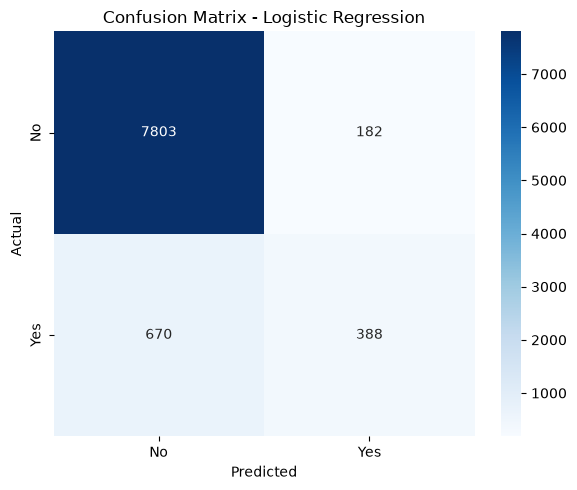

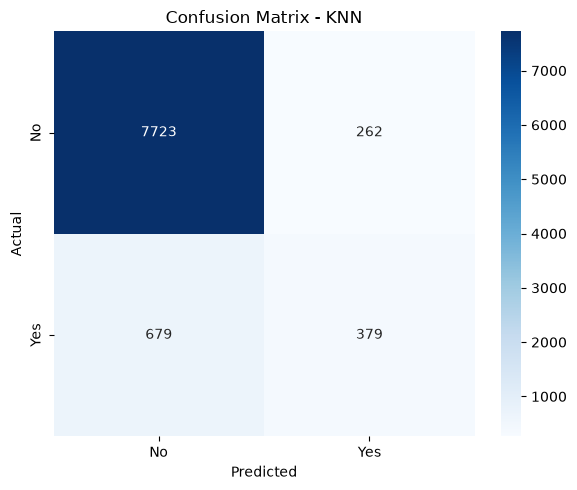

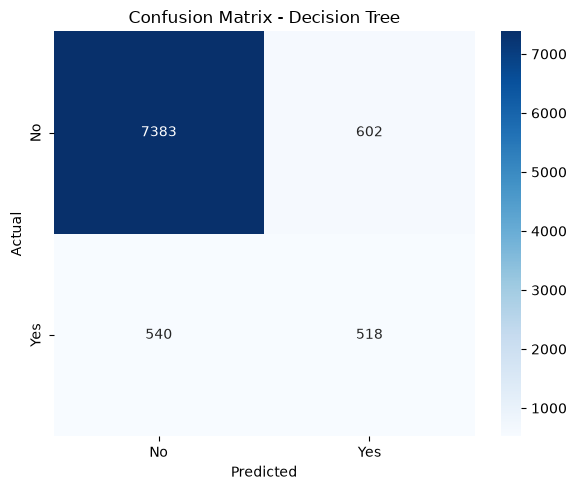

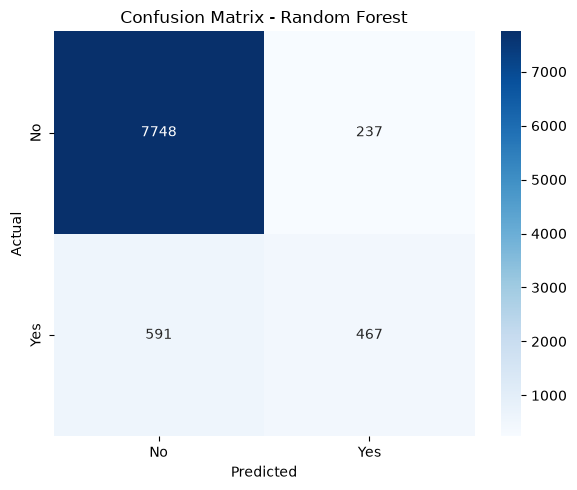

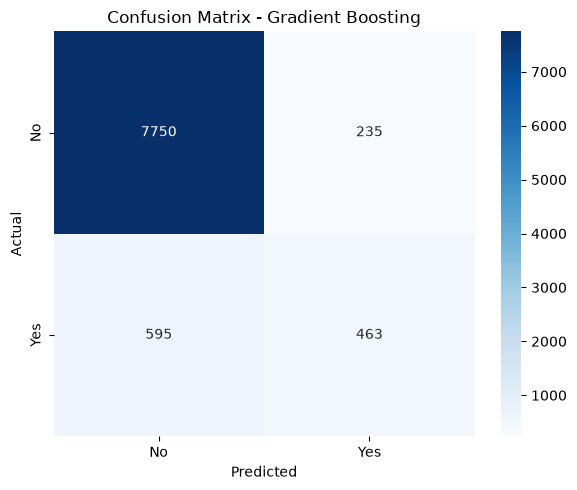

In [48]:
# Confusion matrices for all five models

confusion_matrices = {
    "Logistic Regression": confusion_matrix(y_test, y_pred_logistic),
    "KNN": confusion_matrix(y_test, y_pred_knn),
    "Decision Tree": confusion_matrix(y_test, y_pred_decision_tree),
    "Random Forest": confusion_matrix(y_test, y_pred_random_forest),
    "Gradient Boosting": confusion_matrix(y_test, y_pred_gradient_boosting)
}

for model_name, cm in confusion_matrices.items():
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No", "Yes"],
        yticklabels=["No", "Yes"]
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

### Handling Class Imbalance Using SMOTENC and Stratified K-Fold Cross-Validation
Since the data is heavily imbalanced (89% 'no' vs 11% 'yes'), we evaluate SMOTENC to generate synthetic minority samples. SMOTENC is used because our dataset contains both continuous and categorical variables. It is applied *before* OneHotEncoding to prevent invalid synthetic categories.

In [49]:
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC
import pandas as pd

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=67)

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

categorical_indices = []
for column in categorical_features:
    index = X_train.columns.get_loc(column)
    categorical_indices.append(index)

smotenc = SMOTENC(categorical_features=categorical_indices, random_state=67)

comparison_results = []
smote_pipelines = {} # FIX: Re-initialize the dictionary so downstream cells work!

# LOGISTIC REGRESSION
logistic_model = LogisticRegression(max_iter=1000)
logistic_pipeline = ImbPipeline([
    ("smotenc", smotenc),
    ("preprocessor", preprocessor),
    ("model", logistic_model)
])
smote_pipelines["Logistic Regression"] = logistic_pipeline

logistic_results = cross_validate(
    logistic_pipeline, X_train, y_train, cv=skf,
    scoring=["accuracy", "precision", "recall", "f1"], n_jobs=-1
)
comparison_results.append({
    "Model": "Logistic Regression",
    "CV Accuracy": logistic_results["test_accuracy"].mean(),
    "CV Precision": logistic_results["test_precision"].mean(),
    "CV Recall": logistic_results["test_recall"].mean(),
    "CV F1 Score": logistic_results["test_f1"].mean()
})

# KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_pipeline = ImbPipeline([
    ("smotenc", smotenc),
    ("preprocessor", preprocessor),
    ("model", knn_model)
])
smote_pipelines["KNN"] = knn_pipeline

knn_results = cross_validate(
    knn_pipeline, X_train, y_train, cv=skf,
    scoring=["accuracy", "precision", "recall", "f1"], n_jobs=-1
)
comparison_results.append({
    "Model": "KNN",
    "CV Accuracy": knn_results["test_accuracy"].mean(),
    "CV Precision": knn_results["test_precision"].mean(),
    "CV Recall": knn_results["test_recall"].mean(),
    "CV F1 Score": knn_results["test_f1"].mean()
})

# DECISION TREE
decision_tree_model = DecisionTreeClassifier(random_state=67)
decision_tree_pipeline = ImbPipeline([
    ("smotenc", smotenc),
    ("preprocessor", preprocessor),
    ("model", decision_tree_model)
])
smote_pipelines["Decision Tree"] = decision_tree_pipeline

decision_tree_results = cross_validate(
    decision_tree_pipeline, X_train, y_train, cv=skf,
    scoring=["accuracy", "precision", "recall", "f1"], n_jobs=-1
)
comparison_results.append({
    "Model": "Decision Tree",
    "CV Accuracy": decision_tree_results["test_accuracy"].mean(),
    "CV Precision": decision_tree_results["test_precision"].mean(),
    "CV Recall": decision_tree_results["test_recall"].mean(),
    "CV F1 Score": decision_tree_results["test_f1"].mean()
})

# RANDOM FOREST
random_forest_model = RandomForestClassifier(random_state=67)
random_forest_pipeline = ImbPipeline([
    ("smotenc", smotenc),
    ("preprocessor", preprocessor),
    ("model", random_forest_model)
])
smote_pipelines["Random Forest"] = random_forest_pipeline

random_forest_results = cross_validate(
    random_forest_pipeline, X_train, y_train, cv=skf,
    scoring=["accuracy", "precision", "recall", "f1"], n_jobs=-1
)
comparison_results.append({
    "Model": "Random Forest",
    "CV Accuracy": random_forest_results["test_accuracy"].mean(),
    "CV Precision": random_forest_results["test_precision"].mean(),
    "CV Recall": random_forest_results["test_recall"].mean(),
    "CV F1 Score": random_forest_results["test_f1"].mean()
})

# GRADIENT BOOSTING
gradient_boosting_model = GradientBoostingClassifier(random_state=67)
gradient_boosting_pipeline = ImbPipeline([
    ("smotenc", smotenc),
    ("preprocessor", preprocessor),
    ("model", gradient_boosting_model)
])
smote_pipelines["Gradient Boosting"] = gradient_boosting_pipeline

gradient_boosting_results = cross_validate(
    gradient_boosting_pipeline, X_train, y_train, cv=skf,
    scoring=["accuracy", "precision", "recall", "f1"], n_jobs=-1
)
comparison_results.append({
    "Model": "Gradient Boosting",
    "CV Accuracy": gradient_boosting_results["test_accuracy"].mean(),
    "CV Precision": gradient_boosting_results["test_precision"].mean(),
    "CV Recall": gradient_boosting_results["test_recall"].mean(),
    "CV F1 Score": gradient_boosting_results["test_f1"].mean()
})

comparison_df = pd.DataFrame(comparison_results)
display(comparison_df)

/var/folders/cr/y1f52cs97lj9bhxjpkfh43cr0000gn/T/ipykernel_7879/1721464157.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()


,Model,CV Accuracy,CV Precision,CV Recall,CV F1 Score
0,Logistic Regression,0.853849,0.427847,0.738835,0.541851
1,KNN,0.858494,0.432937,0.673602,0.527027
2,Decision Tree,0.854955,0.417898,0.610256,0.496042
3,Random Forest,0.885424,0.507780,0.685183,0.583140
4,Gradient Boosting,0.856807,0.437821,0.786576,0.562483


### Generating Predictions via Cross-Validation

In [50]:
# 2. PREDICTING PHASE (Out-of-Fold Predictions)
# We generate actual predictions for every training sample using cross_val_predict
cv_predictions = {}

for model_name, pipeline in smote_pipelines.items():
    print(f"Generating CV predictions for {model_name}...")
    y_pred_cv = cross_val_predict(pipeline, X_train, y_train, cv=skf, n_jobs=-1)
    cv_predictions[model_name] = y_pred_cv

print("Predictions generated successfully.")

Generating CV predictions for Logistic Regression...
Generating CV predictions for KNN...
Generating CV predictions for Decision Tree...
Generating CV predictions for Random Forest...
Generating CV predictions for Gradient Boosting...
Predictions generated successfully.


### Plotting Confusion Matrices for SMOTENC Models

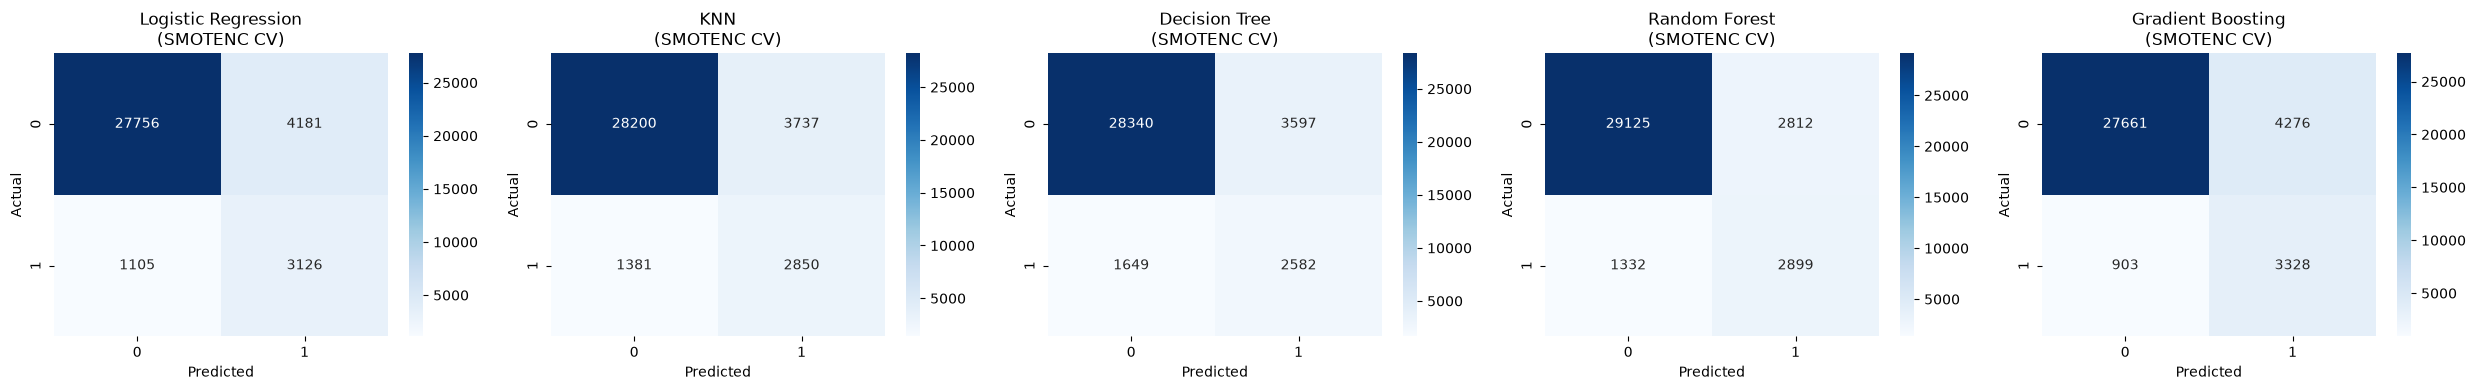

In [51]:
# 3. CONFUSION MATRIX PHASE
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 5, figsize=(25, 4))

for i, (model_name, y_pred_cv) in enumerate(cv_predictions.items()):
    cm = confusion_matrix(y_train, y_pred_cv)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f"{model_name}\n(SMOTENC CV)")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.tight_layout()
plt.show()

### Contact Duration Analysis & Realistic Model
**Why must contact duration be treated with caution?**
`duration` is highly predictive, but it is fundamentally unknown *before* a call is made. Using it in a predictive model deployed to decide *who* to call is data leakage. We must build and cross-validate a model without the `duration` feature.

In [52]:
# Drop 'duration' from the dataset
X_real = X.drop(columns=['duration'])
numeric_features_real = [f for f in numeric_features if f != 'duration']

# Stratified Split (Point 5 fix: add stratify=y)
X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
    X_real,
    y,
    test_size=0.20,
    random_state=67,
    stratify=y
)

preprocessor_real = ColumnTransformer(
    transformers=[
        ("numerical", StandardScaler(), numeric_features_real),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)


### Stratified CV of Realistic Models (No Duration)
We re-evaluate all 5 models (using SMOTENC) on the realistic dataset to select the final deployment candidate.

In [53]:
# Models to evaluate (realistic evaluation without duration)
models_to_compare = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=67),
    "Random Forest": RandomForestClassifier(random_state=67),
    "Gradient Boosting": GradientBoostingClassifier(random_state=67)
}

scoring_metrics = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

realistic_results = []
categorical_indices_real = [X_train_real.columns.get_loc(col) for col in categorical_features]

smotenc_real = SMOTENC(categorical_features=categorical_indices_real, random_state=67)

for model_name, model in models_to_compare.items():
    pipe_real = ImbPipeline(
        steps=[
            ("smotenc", smotenc_real),
            ("preprocessor", preprocessor_real),
            ("model", model)
        ]
    )
    cv_real = cross_validate(
        pipe_real,
        X_train_real,
        y_train_real,
        cv=skf,
        scoring=scoring_metrics,
        n_jobs=-1
    )
    realistic_results.append({
        "Model": model_name,
        "CV Accuracy": cv_real["test_accuracy"].mean(),
        "CV Precision": cv_real["test_precision"].mean(),
        "CV Recall": cv_real["test_recall"].mean(),
        "CV F1 Score": cv_real["test_f1"].mean()
    })

real_comparison_df = pd.DataFrame(realistic_results).sort_values(by="CV Precision", ascending=False)
display(real_comparison_df)


NameError: name 'models_to_compare' is not defined

### Final Model Selection & Feature Importance
Based on the CV results, Gradient Boosting and Random Forest generally balance Precision and Recall best. We will train the Final Gradient Boosting Model with SMOTENC on the entire training set.

/var/folders/cr/y1f52cs97lj9bhxjpkfh43cr0000gn/T/ipykernel_9087/1555060169.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df.head(10), x='Importance', y='Feature', palette='viridis')


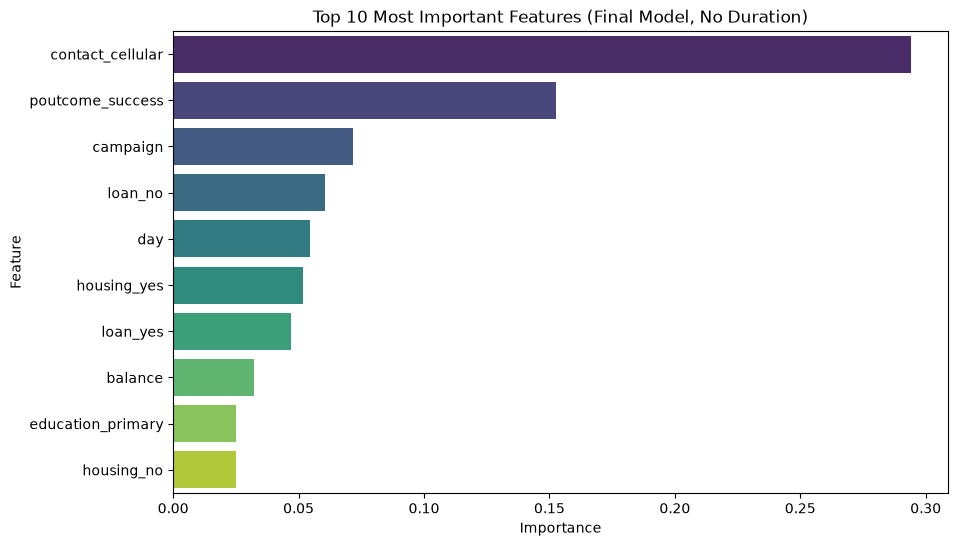

In [ ]:
# Train final model on full train set
final_pipeline = ImbPipeline(
    steps=[
        ("smotenc", smotenc_real),
        ("preprocessor", preprocessor_real),
        ("model", GradientBoostingClassifier(random_state=67))
    ]
)
final_pipeline.fit(X_train_real, y_train_real)

# Extract Feature Importances from final model
final_model_step = final_pipeline.named_steps["model"]
importances = final_model_step.feature_importances_

cat_encoder = final_pipeline.named_steps['preprocessor'].named_transformers_['categorical']
try:
    cat_features_out = cat_encoder.get_feature_names_out(categorical_features)
except:
    cat_features_out = cat_encoder.get_feature_names(categorical_features)

feature_names_real = list(numeric_features_real) + list(cat_features_out)
feat_imp_df = pd.DataFrame({'Feature': feature_names_real, 'Importance': importances}).sort_values(by='Importance', ascending=False)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df.head(10), x='Importance', y='Feature', palette='viridis')
plt.title("Top 10 Most Important Features (Final Model, No Duration)")
plt.show()


### Campaign Cost Analysis on Test Set
We evaluate the final model on the untouched test set and perform a proper cost analysis separating True Positives (useful calls) from False Positives (unnecessary calls).

In [ ]:
from sklearn.metrics import confusion_matrix

y_pred_final = final_pipeline.predict(X_test_real)
cm_final = confusion_matrix(y_test_real, y_pred_final)
TN, FP, FN, TP = cm_final.ravel()

total_customers = len(y_test_real)
predicted_yes = TP + FP
predicted_no = TN + FN

print(f"--- Cost Analysis (Test Set of {total_customers} customers) ---")
print(f"Total customers: {total_customers}")
print(f"Predicted YES (Calls to make): {predicted_yes} ({(predicted_yes/total_customers)*100:.1f}%)")
print(f"Predicted NO (Calls avoided): {predicted_no} ({(predicted_no/total_customers)*100:.1f}%)")
print(f"  - True Positives (Useful calls, got subscriber): {TP}")
print(f"  - False Positives (Unnecessary calls, no subscriber): {FP}")
print(f"  - True Negatives (Genuinely avoided calling a non-subscriber): {TN}")
print(f"  - False Negatives (Missed a potential subscriber): {FN}")

# Hypothetical Cost Calculation
print(f"\n--- Hypothetical Time Savings ---")
print("Assuming average call takes 5 minutes:")
print(f"Minutes saved by avoiding {predicted_no} calls = {predicted_no * 5} minutes ({(predicted_no * 5)/60:.1f} hours)")


--- Cost Analysis (Test Set of 9043 customers) ---
Total customers: 9043
Predicted YES (Calls to make): 2491 (27.5%)
Predicted NO (Calls avoided): 6552 (72.5%)
  - True Positives (Useful calls, got subscriber): 648
  - False Positives (Unnecessary calls, no subscriber): 1843
  - True Negatives (Genuinely avoided calling a non-subscriber): 6142
  - False Negatives (Missed a potential subscriber): 410

--- Hypothetical Time Savings ---
Assuming average call takes 5 minutes:
Minutes saved by avoiding 6552 calls = 32760 minutes (546.0 hours)


### Deployment
Export the finalized pipeline for Streamlit.

In [ ]:
import joblib
import os

os.makedirs('model', exist_ok=True)
joblib.dump(final_pipeline, 'model/final_bank_model_smotenc.pkl')
joblib.dump(list(X_real.columns), 'model/final_feature_columns.pkl')

print("Final Pipeline and Feature Columns exported successfully!")


Final Pipeline and Feature Columns exported successfully!
